# SABER Excytin Evaluation Analysis

## Purpose

**Self-contained** analysis notebook for the **Excytin** cybersecurity incident response domain. Includes all domain-agnostic analysis (scores, cost, tokens, sub-tasks) plus Excytin-specific experiments that use the domain's incident grouping.

**What is Excytin?** A benchmark where AI agents investigate 8 security incidents using database forensics, SQL queries, and evidence analysis — 599 test tasks across incidents like unauthorized access, data exfiltration, and insider threats.

### Analyses included

| # | Analysis | Domain-Agnostic? |
|---|----------|------------------|
| 1 | Overall Reward Distribution | ✓ Generic |
| 2 | **Per-Incident Breakdown** | **Excytin-specific** (requires incident grouping) |
| 3 | Cost Analysis & Pareto | ✓ Generic |
| 4 | Token Usage Breakdown | ✓ Generic |
| 5 | Cost Efficiency (Reward/$) | ✓ Generic |
| 6 | Sub-Task Decomposition | ✓ Generic |
| 7 | Checkpoint Distributions | ✓ Generic |
| 8 | **Submission vs. Checkpoint Gap Heatmap** | **Excytin-specific** (per-incident gap analysis) |

> **Domain-specific experiments (2 & 8)** require a `GROUP_FN` that maps sample IDs to Excytin incidents. Each SABER domain defines its own grouping — see [`eval_analysis.ipynb`](eval_analysis.ipynb) for configuration details and examples for other domains.

For domain-agnostic analysis applicable to any domain, see [`eval_analysis.ipynb`](eval_analysis.ipynb).

### Sample models

| Model | API ID | Provider |
|-------|--------|----------|
| Claude Haiku 4.5 | `anthropic/claude-haiku-4-5` | Anthropic |
| Claude Sonnet 4.6 | `anthropic/claude-sonnet-4-6` | Anthropic |
| Claude Opus 4.6 | `anthropic/claude-opus-4-6` | Anthropic |
| GPT-5.4 | `openai/azure/gpt-5.4` | Azure OpenAI |
| GPT-5.4-mini | `openai/azure/gpt-5.4-mini-2026-03-17` | Azure OpenAI |

## Prerequisites & Running Excytin Evaluations

```bash
# Install
uv sync --all-extras
cp .env.template .env  # Configure API keys

# Quick test (10 samples)
uv run inspect eval domains/excytin --model anthropic/claude-haiku-4-5 --limit 10

# Full evaluation (599 samples)
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6

# With parallel execution
uv run inspect eval domains/excytin --model anthropic/claude-sonnet-4-6 \\
  --max-samples 4 --max-connections 20
```

### Viewing results

- **VS Code:** Install the **Inspect AI** extension → click any `.eval` file
- **Browser:** `uv run inspect view` → http://localhost:7575

Copy `.eval` files to `latest_experiments/excytin/` with descriptive names. See [README.md](../README.md) for full documentation.

<a id="configuration"></a>
## Configuration

Edit the cell below to add your own models. See [`eval_analysis.ipynb`](eval_analysis.ipynb) for detailed configuration instructions.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — Excytin domain
# ══════════════════════════════════════════════════════════════════════════════
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

NOTEBOOK_DIR = Path('.').resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from saber_analysis.data_loader import load_eval_logs, load_baseline_logs, ensure_eval_files
from saber_analysis.cost import extract_cost_rows
from saber_analysis.plots import setup_plotting, classify_score_type

setup_plotting()

DOMAIN_NAME = 'Excytin'
DOMAIN_SLUG = 'excytin'
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
LOG_DIR = str(REPO_ROOT / 'eval_samples' / DOMAIN_SLUG)
ARTIFACTS_DIR = NOTEBOOK_DIR / 'artifacts' / 'excytin'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

EVAL_LOGS = {
    'Claude Haiku 4.5':  'haiku_4.5_latest_test_set.eval',
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set.eval',
}

NO_THINKING_LOGS = {
    'Claude Sonnet 4.6': 'sonnet_4.6_latest_test_set_no_thinking.eval',
    'Claude Opus 4.6':   'opus_4.6_latest_test_set_no_thinking.eval',
    'GPT-5.4':           'gpt_5.4_latest_test_set_no_reasoning.eval',
    'GPT-5.4-mini':      'gpt_5.4_mini_latest_test_set_no_reasoning.eval',
}

COLORS = {
    'Claude Haiku 4.5':  '#1ABC9C',
    'Claude Sonnet 4.6': '#F39C12',
    'Claude Opus 4.6':   '#E74C3C',
    'GPT-5.4':           '#27AE60',
    'GPT-5.4-mini':      '#2E86C1',
}

N_SAMPLES = 599
MODEL_ORDER = list(EVAL_LOGS.keys())

# Excytin groups by security incident
GROUP_FN = lambda sid: '_'.join(sid.split('_')[:2])
GROUP_LABEL = 'Incident'

PRICING = {
    'anthropic/claude-haiku-4-5':            {'input': 0.80,  'output': 4.00,  'cache_read': 0.08,   'cache_write': 1.00},
    'anthropic/claude-sonnet-4-6':           {'input': 3.00,  'output': 15.00, 'cache_read': 0.375,  'cache_write': 3.75},
    'anthropic/claude-opus-4-6':             {'input': 15.00, 'output': 75.00, 'cache_read': 1.875,  'cache_write': 18.75},
    'openai/azure/gpt-5.4':                  {'input': 10.00, 'output': 30.00, 'cache_read': 2.50,   'cache_write': 0.0},
    'openai/azure/gpt-5.4-mini-2026-03-17':  {'input': 1.10,  'output': 4.40,  'cache_read': 0.275,  'cache_write': 0.0},
}

# Ensure eval files exist locally, download from HuggingFace if needed.
# Checks LOG_DIR first, then latest_experiments/ as fallback, then HuggingFace.
ensure_eval_files(
    EVAL_LOGS, LOG_DIR, DOMAIN_SLUG,
    baseline_logs=NO_THINKING_LOGS,
    fallback_dirs=[str(REPO_ROOT / 'latest_experiments' / DOMAIN_SLUG)],
)

print(f'✓ Domain: {DOMAIN_NAME}')
print(f'  Models: {len(EVAL_LOGS)} ({", ".join(MODEL_ORDER)})')
print(f'  Samples: {N_SAMPLES}')
print(f'  Log dir: {LOG_DIR}')

✓ All 9 eval files found locally in /home/amudgerikar/repos/oss_saber/latest_experiment_samples/excytin
✓ Domain: Excytin
  Models: 5 (Claude Haiku 4.5, Claude Sonnet 4.6, Claude Opus 4.6, GPT-5.4, GPT-5.4-mini)
  Samples: 599
  Log dir: /home/amudgerikar/repos/oss_saber/latest_experiment_samples/excytin


## Data Loading

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
samples_df, subtasks_df, overall_df, model_overall = load_eval_logs(
    EVAL_LOGS, LOG_DIR, MODEL_ORDER, group_fn=GROUP_FN
)
baseline_samples_df, baseline_subtasks_df, no_thinking_overall = load_baseline_logs(
    NO_THINKING_LOGS, LOG_DIR, group_fn=GROUP_FN
)

print(f'\n✓ Loaded {len(samples_df)} sample scores across {samples_df["model"].nunique()} models')
print(f'✓ Loaded {len(subtasks_df)} sub-task scores')
print(f'✓ Incidents: {sorted(samples_df["group"].unique())}')
print()
print('═══ Overall SABER Scores (with extended reasoning) ═══')
for m in MODEL_ORDER:
    if m in model_overall:
        r = overall_df.loc[m]
        print(f'  {m:25s}  mean={r["mean"]:.4f}  stderr={r["stderr"]:.4f}')
print()
print('═══ Baselines (without extended reasoning) ═══')
for m, r in no_thinking_overall.items():
    if m in model_overall:
        delta = model_overall[m]['mean'] - r['mean']
        print(f'  {m:25s}  baseline={r["mean"]:.4f}  reasoning={model_overall[m]["mean"]:.4f}  Δ={delta:+.4f}')


✓ Loaded 2995 sample scores across 5 models
✓ Loaded 12985 sub-task scores
✓ Incidents: ['incident_134', 'incident_166', 'incident_322', 'incident_34', 'incident_38', 'incident_39', 'incident_5', 'incident_55']

═══ Overall SABER Scores (with extended reasoning) ═══
  Claude Haiku 4.5           mean=0.8381  stderr=0.0125
  Claude Sonnet 4.6          mean=0.8567  stderr=0.0116
  Claude Opus 4.6            mean=0.8649  stderr=0.0115
  GPT-5.4                    mean=0.8752  stderr=0.0106
  GPT-5.4-mini               mean=0.8265  stderr=0.0145

═══ Baselines (without extended reasoning) ═══
  Claude Sonnet 4.6          baseline=0.8222  reasoning=0.8567  Δ=+0.0345
  Claude Opus 4.6            baseline=0.8745  reasoning=0.8649  Δ=-0.0096
  GPT-5.4                    baseline=0.8044  reasoning=0.8752  Δ=+0.0708
  GPT-5.4-mini               baseline=0.7442  reasoning=0.8265  Δ=+0.0824


---

## 1. Overall Reward Distribution per Model

Mean `saber_overall` score across all 599 test samples. Solid bars = default; hatched = Δ from extended reasoning. Error bars = standard error.

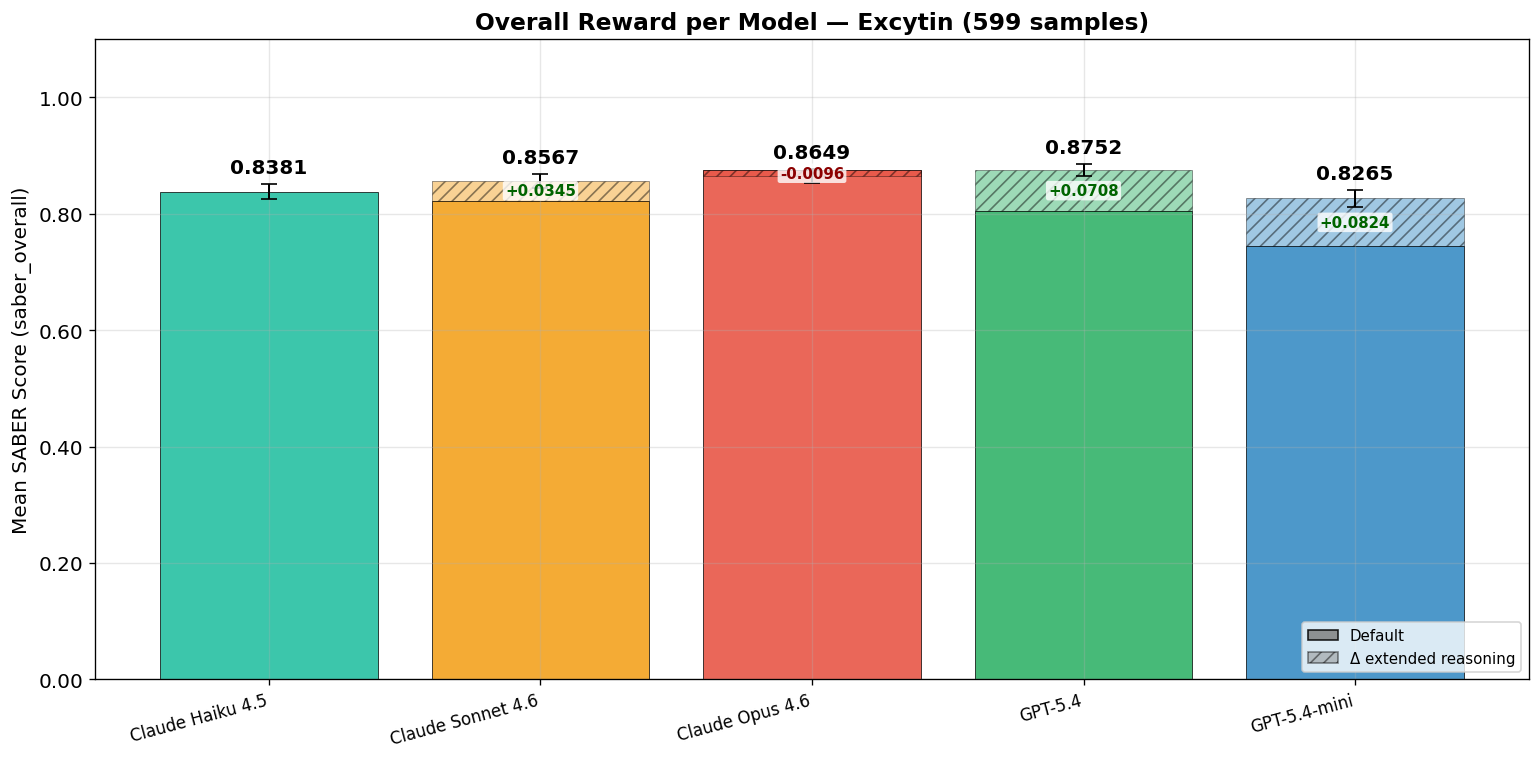

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: Overall mean scores
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6.5))
means = [overall_df.loc[m, 'mean'] for m in MODEL_ORDER]
stderrs = [overall_df.loc[m, 'stderr'] for m in MODEL_ORDER]
colors = [COLORS[m] for m in MODEL_ORDER]

base_heights, delta_heights = [], []
for m in MODEL_ORDER:
    if m in no_thinking_overall:
        base_heights.append(no_thinking_overall[m]['mean'])
        delta_heights.append(overall_df.loc[m, 'mean'] - no_thinking_overall[m]['mean'])
    else:
        base_heights.append(overall_df.loc[m, 'mean'])
        delta_heights.append(0.0)

x = np.arange(len(MODEL_ORDER))
ax.bar(x, base_heights, color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
for i, m in enumerate(MODEL_ORDER):
    if delta_heights[i] != 0:
        ax.bar(i, abs(delta_heights[i]),
               bottom=base_heights[i] if delta_heights[i] > 0 else base_heights[i] + delta_heights[i],
               color=colors[i], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
ax.errorbar(x, means, yerr=stderrs, fmt='none', ecolor='black', capsize=5, linewidth=1.2)
for i, (mean, se) in enumerate(zip(means, stderrs)):
    ax.text(i, mean + se + 0.012, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for i, m in enumerate(MODEL_ORDER):
    if m in no_thinking_overall:
        d = delta_heights[i]
        ax.text(i, base_heights[i] + d/2, f'{d:+.4f}', ha='center', va='center', fontsize=9, fontweight='bold',
                color='#006400' if d > 0 else '#8B0000',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean SABER Score (saber_overall)')
ax.set_title(f'Overall Reward per Model — Excytin ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.10); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'overall_reward.png', bbox_inches='tight')
plt.show()

---

## 2. Per-Incident Reward Breakdown (Excytin-Specific)

Excytin has **8 security incidents**, each a distinct investigation scenario. This analysis uses the domain's `GROUP_FN` (mapping sample IDs → incidents) to reveal which incidents are universally hard vs. model-dependent.

═══ Per-Incident Mean Scores ═══
model         Claude Haiku 4.5  Claude Sonnet 4.6  Claude Opus 4.6  GPT-5.4  GPT-5.4-mini
group                                                                                    
incident_134            0.9138             0.9569           0.9655   0.9828        0.9655
incident_166            0.8391             0.8563           0.8851   0.9425        0.8736
incident_322            0.8874             0.8626           0.8962   0.8904        0.8406
incident_34             0.9294             0.9353           0.9471   0.9412        0.9647
incident_38             0.9167             0.8333           0.8750   0.9167        0.9167
incident_39             0.8142             0.8042           0.8442   0.8033        0.7900
incident_5              0.7842             0.8308           0.8000   0.8058        0.7083
incident_55             0.7562             0.8100           0.7858   0.8258        0.7233


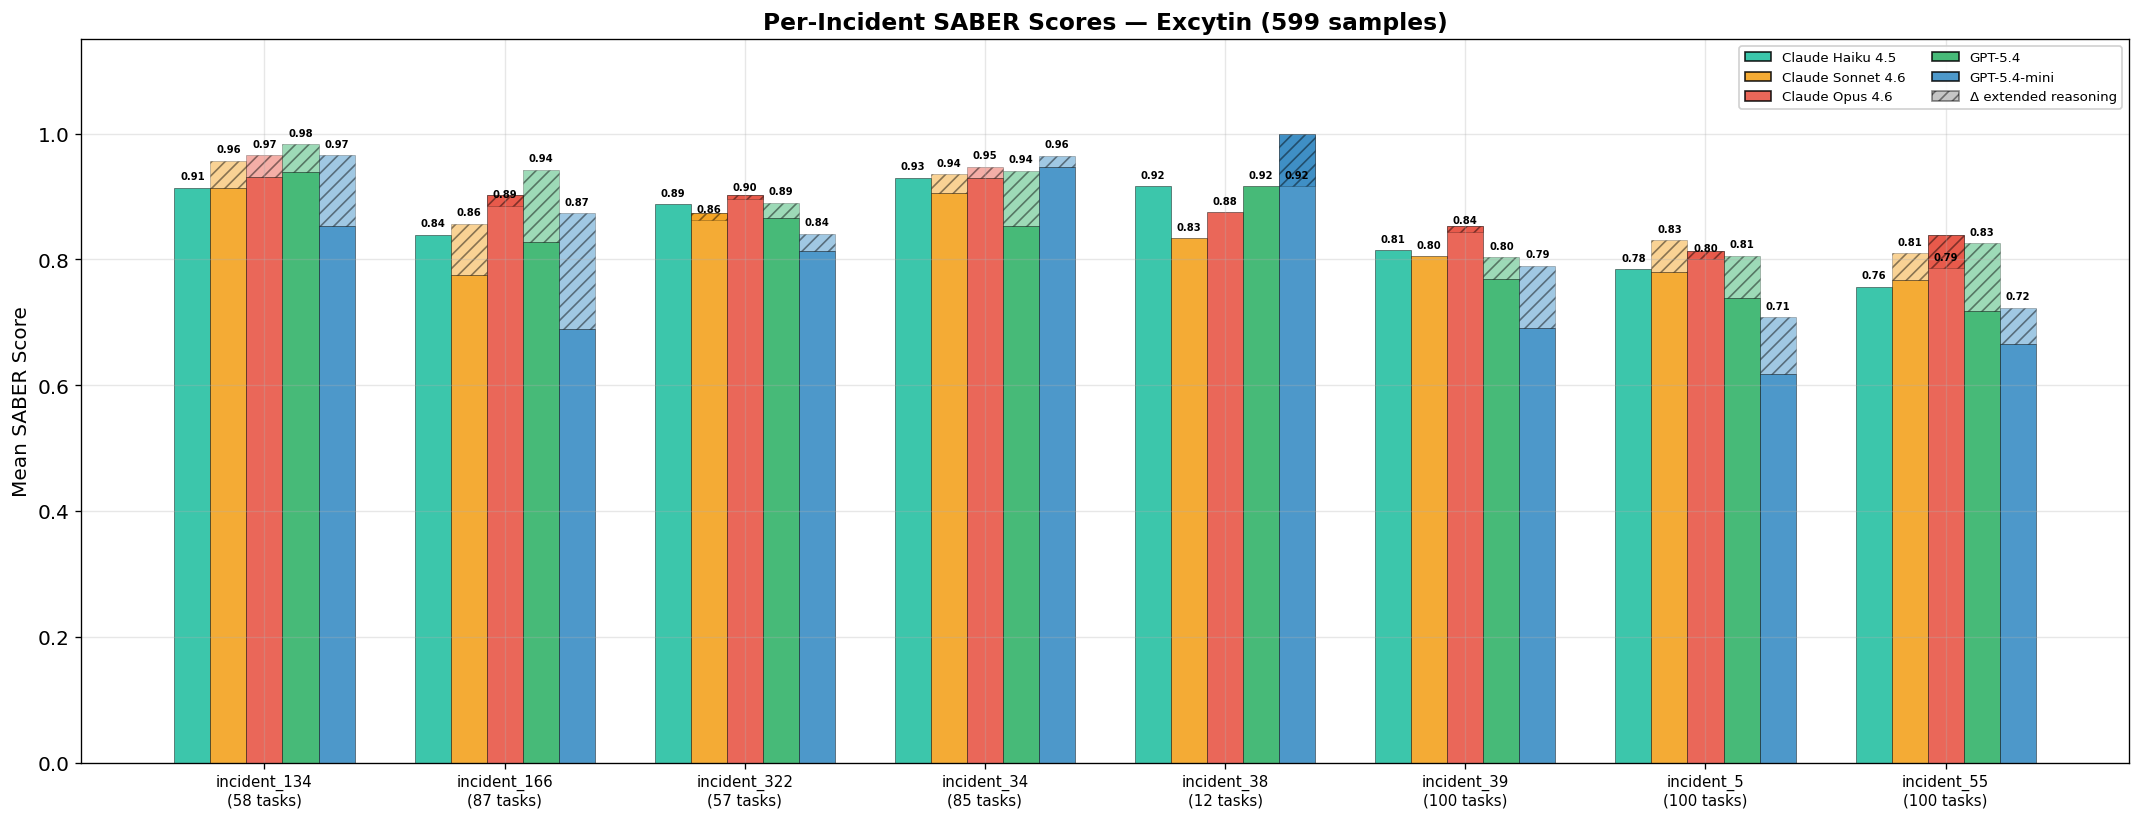

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: Per-incident grouped bar chart
# ══════════════════════════════════════════════════════════════════════════════
group_scores = samples_df.groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER).sort_index()
group_counts = samples_df[samples_df['model'] == MODEL_ORDER[0]].groupby('group').size()

baseline_group = pd.DataFrame()
if len(baseline_samples_df) > 0:
    baseline_group = baseline_samples_df.groupby(['group', 'model'])['score'].mean().unstack('model')
    baseline_group = baseline_group.reindex(index=group_scores.index, columns=MODEL_ORDER)

print('═══ Per-Incident Mean Scores ═══')
print(group_scores.round(4).to_string())

fig, ax = plt.subplots(figsize=(18, 7))
n_groups, n_models = len(group_scores), len(MODEL_ORDER)
bar_width = 0.15
xg = np.arange(n_groups)

for i, model in enumerate(MODEL_ORDER):
    offset = (i - n_models/2 + 0.5) * bar_width
    full_vals = group_scores[model].values
    has_base = model in no_thinking_overall and len(baseline_group) > 0 and model in baseline_group.columns

    if has_base:
        base_vals = baseline_group[model].values
        ax.bar(xg + offset, base_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)
        for xi in range(len(xg)):
            d = full_vals[xi] - base_vals[xi]
            if abs(d) > 0.001:
                ax.bar(xg[xi] + offset, abs(d), bottom=base_vals[xi] if d > 0 else full_vals[xi],
                       width=bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
    else:
        ax.bar(xg + offset, full_vals, bar_width, color=COLORS[model], edgecolor='black', linewidth=0.3, alpha=0.85)

    for xi, v in zip(xg, full_vals):
        ax.text(xi + offset, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=6, fontweight='bold')

handles = [mpatches.Patch(facecolor=COLORS[m], edgecolor='black', alpha=0.85, label=m) for m in MODEL_ORDER]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
ax.set_xticks(xg)
ax.set_xticklabels([f'{g}\n({group_counts.get(g, "?")} tasks)' for g in group_scores.index], fontsize=9)
ax.set_ylabel('Mean SABER Score')
ax.set_title(f'Per-Incident SABER Scores — Excytin ({N_SAMPLES} samples)', fontweight='bold')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'per_incident_scores.png', bbox_inches='tight')
plt.show()

---

## 3. Cost Analysis

Total cost, cost per sample, and Pareto (score vs. cost) tradeoff.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3a: Cost extraction
# ══════════════════════════════════════════════════════════════════════════════
cost_df = pd.DataFrame(extract_cost_rows(EVAL_LOGS, LOG_DIR, PRICING, N_SAMPLES)).set_index('model').reindex(MODEL_ORDER)
_baseline_rows = extract_cost_rows(NO_THINKING_LOGS, LOG_DIR, PRICING, N_SAMPLES)
baseline_cost_df = pd.DataFrame(_baseline_rows).set_index('model') if _baseline_rows else pd.DataFrame()

print('═══ Cost (with extended reasoning) ═══')
print(cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string())
print()
print('═══ Cost (default / no reasoning) ═══')
print(baseline_cost_df[['score', 'total_cost', 'cost_per_sample']].round(2).to_string() if len(baseline_cost_df) > 0 else '(no baseline logs configured)')

═══ Cost (with extended reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Haiku 4.5    0.84       34.95             0.06
Claude Sonnet 4.6   0.86      120.48             0.20
Claude Opus 4.6     0.86      441.78             0.74
GPT-5.4             0.88      671.79             1.12
GPT-5.4-mini        0.83      117.78             0.20

═══ Cost (default / no reasoning) ═══
                   score  total_cost  cost_per_sample
model                                                
Claude Sonnet 4.6   0.82       79.70             0.13
Claude Opus 4.6     0.87      429.37             0.72
GPT-5.4             0.80      254.77             0.43
GPT-5.4-mini        0.74       54.75             0.09


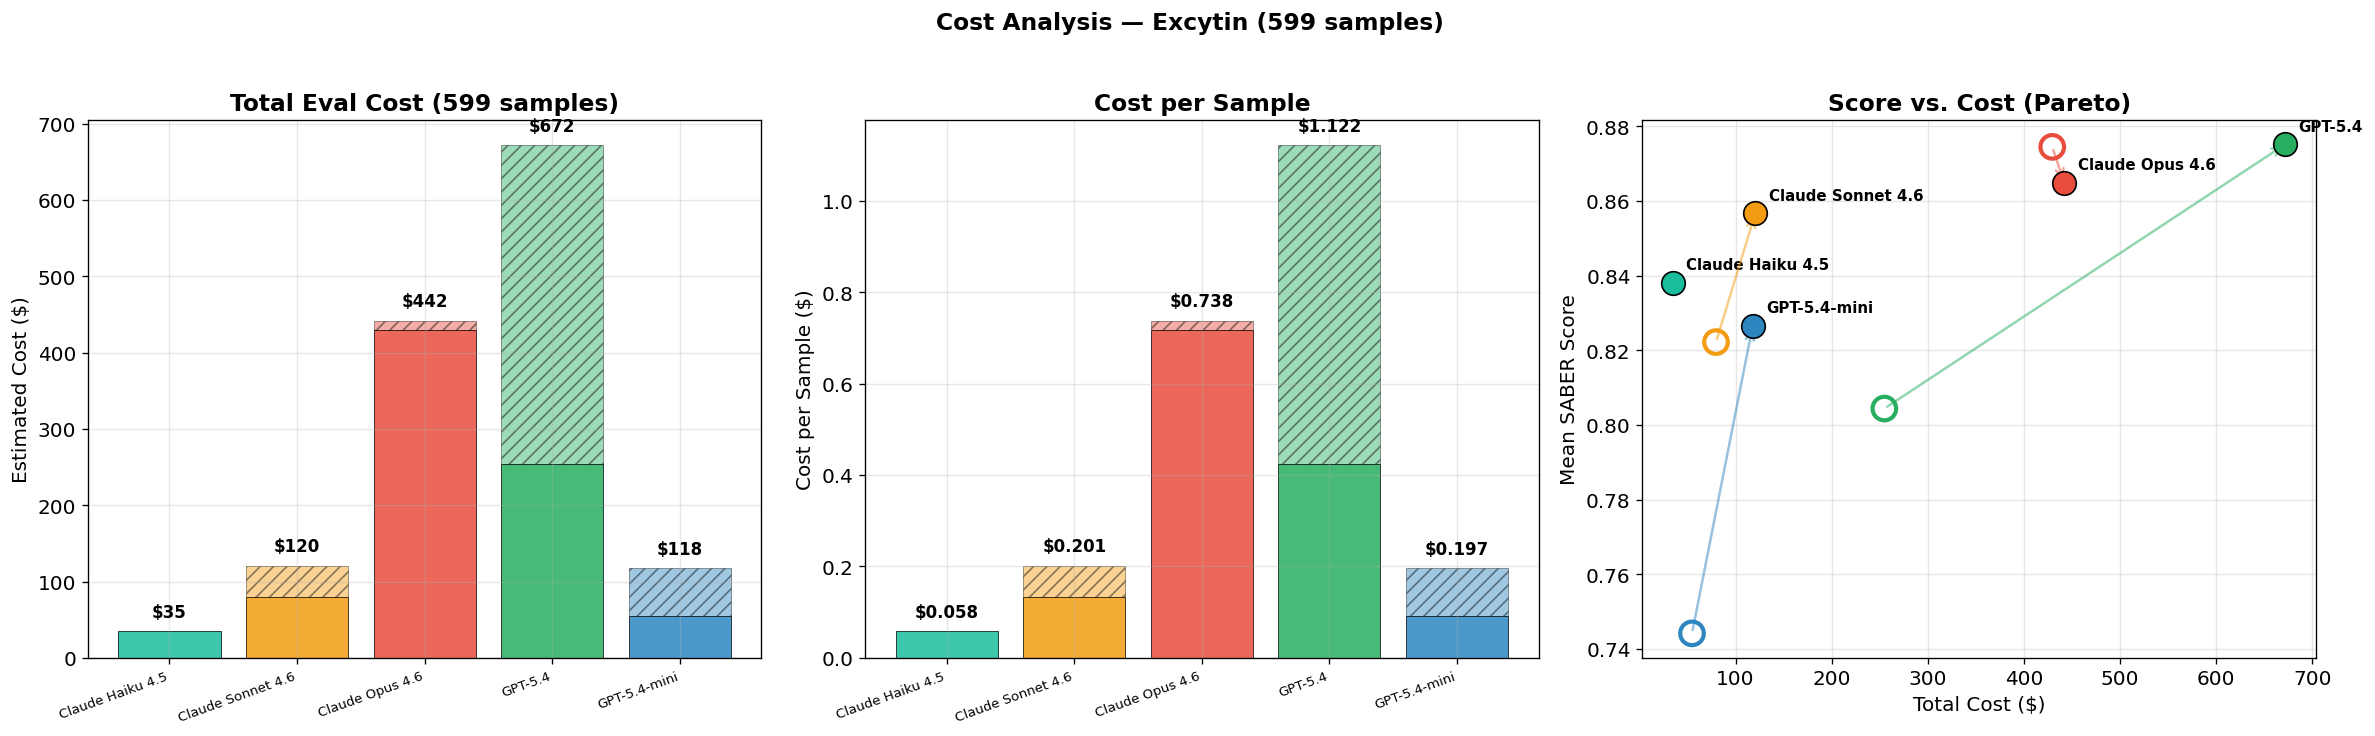

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 3b: Cost visualization
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(MODEL_ORDER))

for panel, (col, ylabel, title, fmt) in enumerate([
    ('total_cost', 'Estimated Cost ($)', f'Total Eval Cost ({N_SAMPLES} samples)', '${:.0f}'),
    ('cost_per_sample', 'Cost per Sample ($)', 'Cost per Sample', '${:.3f}'),
]):
    ax = axes[panel]
    for i, m in enumerate(MODEL_ORDER):
        val = cost_df.loc[m, col]
        if m in baseline_cost_df.index:
            base = baseline_cost_df.loc[m, col]
            ax.bar(i, base, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
            d = val - base
            ax.bar(i, abs(d), bottom=base if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.text(i, val + cost_df[col].max()*0.02, fmt.format(val), ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')

ax = axes[2]
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    ax.scatter(row['total_cost'], row['score'], s=200, color=COLORS[m], edgecolor='black', linewidth=1, zorder=5)
    ax.annotate(m, (row['total_cost'], row['score']), textcoords='offset points', xytext=(8, 8), fontsize=9, fontweight='bold')
for m in baseline_cost_df.index:
    if m not in COLORS: continue
    brow = baseline_cost_df.loc[m]
    ax.scatter(brow['total_cost'], brow['score'], s=200, facecolors='none', edgecolors=COLORS[m], linewidth=2.5, zorder=4)
    ax.annotate('', xy=(cost_df.loc[m, 'total_cost'], cost_df.loc[m, 'score']), xytext=(brow['total_cost'], brow['score']),
                arrowprops=dict(arrowstyle='->', color=COLORS[m], lw=1.5, alpha=0.5))
ax.set_xlabel('Total Cost ($)'); ax.set_ylabel('Mean SABER Score'); ax.set_title('Score vs. Cost (Pareto)', fontweight='bold')

fig.suptitle(f'Cost Analysis — Excytin ({N_SAMPLES} samples)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_analysis.png', bbox_inches='tight')
plt.show()

---

## 4. Token Usage Breakdown

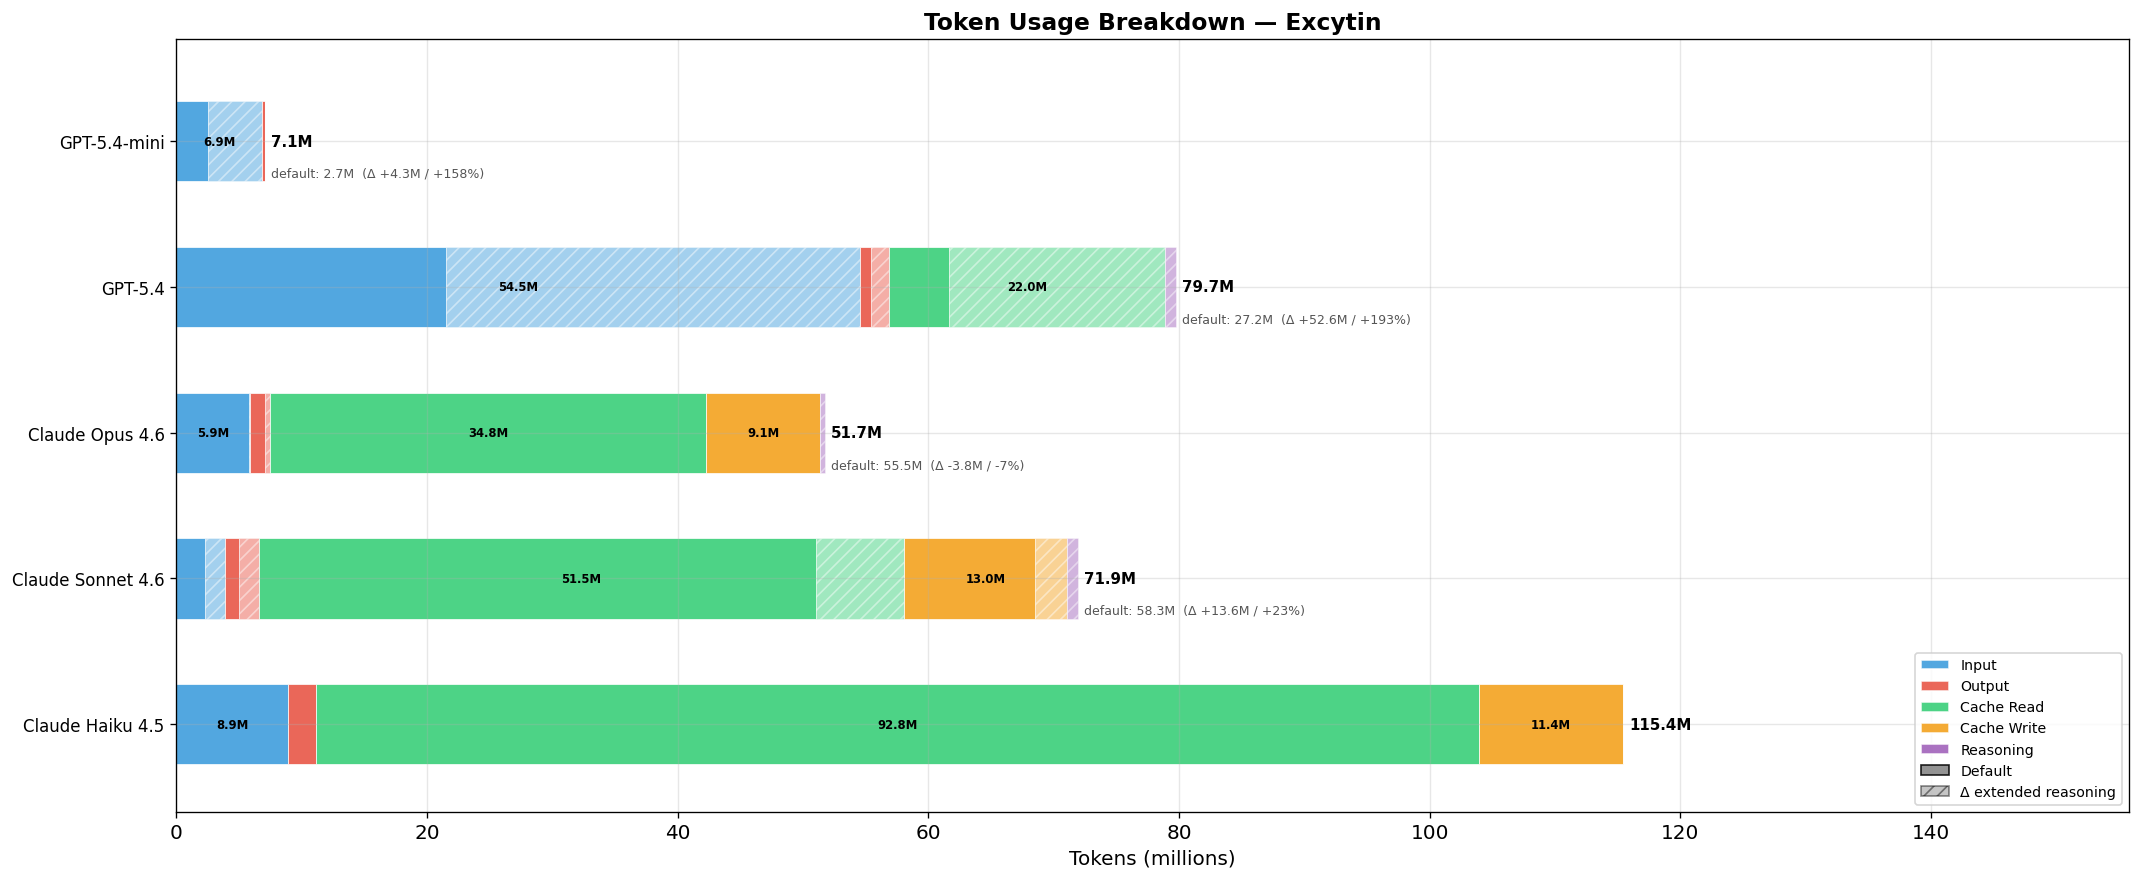

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 4: Token usage stacked horizontal bars
# ══════════════════════════════════════════════════════════════════════════════
categories = ['Input', 'Output', 'Cache Read', 'Cache Write', 'Reasoning']
cat_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
token_keys = ['input_tokens', 'output_tokens', 'cache_read', 'cache_write', 'reasoning_tokens']

fig, ax = plt.subplots(figsize=(18, 7.5))
bar_height = 0.55
all_totals = [sum(cost_df.loc[m][k]/1e6 for k in token_keys) for m in MODEL_ORDER]
global_max = max(all_totals)
MIN_LABEL_WIDTH = global_max * 0.05

for i, m in enumerate(MODEL_ORDER):
    row = cost_df.loc[m]
    vals = [row[k]/1e6 for k in token_keys]
    has_baseline = m in baseline_cost_df.index
    bvals = [baseline_cost_df.loc[m][k]/1e6 for k in token_keys] if has_baseline else vals

    left = 0
    for j, (rv, bv, c) in enumerate(zip(vals, bvals, cat_colors)):
        if has_baseline and rv > 0:
            solid_w = min(rv, bv)
            ax.barh(i, solid_w, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
            if rv - bv > 0.01:
                ax.barh(i, rv - bv, left=left + solid_w, height=bar_height, color=c,
                        edgecolor='white', linewidth=0.5, alpha=0.45, hatch='///')
        else:
            ax.barh(i, rv, left=left, height=bar_height, color=c, edgecolor='white',
                    linewidth=0.5, alpha=0.85, label=categories[j] if i == 0 else '')
        if rv >= MIN_LABEL_WIDTH:
            ax.text(left + rv/2, i, f'{rv:.1f}M', ha='center', va='center', fontsize=7, fontweight='bold')
        left += rv

    ax.text(left + 0.5, i, f'{sum(vals):.1f}M', va='center', ha='left', fontsize=9, fontweight='bold')
    if has_baseline:
        bt = sum(bvals); td = sum(vals) - bt
        ax.text(left + 0.5, i - 0.22, f'default: {bt:.1f}M  (Δ {td:+.1f}M / {td/bt*100:+.0f}%)',
                va='center', ha='left', fontsize=7.5, fontstyle='italic', color='#555')

ax.set_yticks(range(len(MODEL_ORDER))); ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_xlabel('Tokens (millions)'); ax.set_title('Token Usage Breakdown — Excytin', fontweight='bold')
ax.set_xlim(right=global_max * 1.35); ax.set_ylim(-0.6, len(MODEL_ORDER) - 0.3)
legend_handles = [mpatches.Patch(facecolor=c, edgecolor='white', alpha=0.85, label=cat) for cat, c in zip(categories, cat_colors)]
legend_handles += [mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'token_usage.png', bbox_inches='tight')
plt.show()

---

## 5. Cost Efficiency: Reward per Dollar

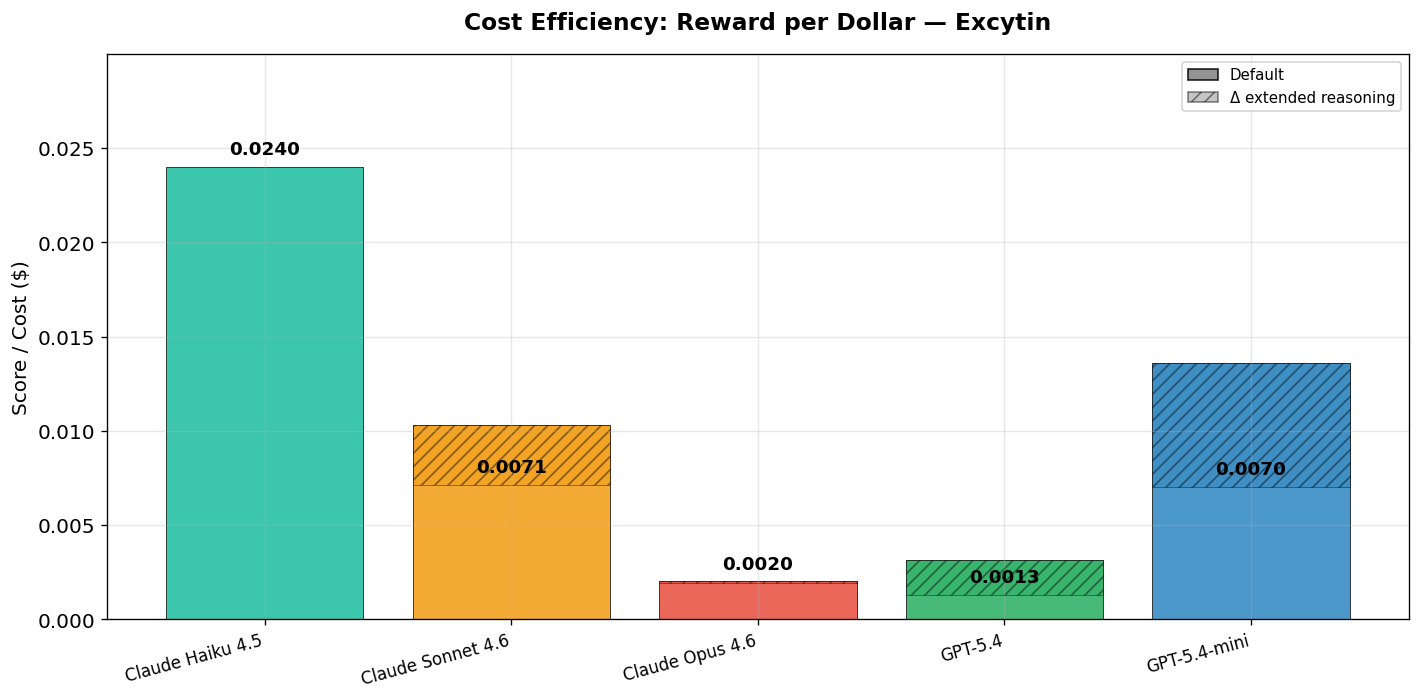

═══ Cost Efficiency Summary ═══
Model                      Score     Cost   $/sample    Score/$
────────────────────────────────────────────────────────────
Claude Haiku 4.5           0.838 $  34.95 $   0.0584    0.02398
Claude Sonnet 4.6          0.857 $ 120.48 $   0.2011    0.00711
Claude Opus 4.6            0.865 $ 441.78 $   0.7375    0.00196
GPT-5.4                    0.875 $ 671.79 $   1.1215    0.00130
GPT-5.4-mini               0.827 $ 117.78 $   0.1966    0.00702


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 5: Cost efficiency
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))
rpd = cost_df['score'] / cost_df['total_cost']
base_rpd = baseline_cost_df['score'] / baseline_cost_df['total_cost'] if len(baseline_cost_df) > 0 else pd.Series(dtype=float)

for i, m in enumerate(MODEL_ORDER):
    val = rpd[m]
    if m in base_rpd.index:
        bv = base_rpd[m]
        ax.bar(i, bv, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
        d = val - bv
        ax.bar(i, abs(d), bottom=bv if d > 0 else val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.45, hatch='///')
    else:
        ax.bar(i, val, color=COLORS[m], edgecolor='black', linewidth=0.5, alpha=0.85)
    ax.text(i, val + rpd.max()*0.02, f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Score / Cost ($)'); ax.set_title('Cost Efficiency: Reward per Dollar — Excytin', fontweight='bold', pad=15)
ax.set_ylim(0, rpd.max() * 1.25)
ax.legend(handles=[mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.85, label='Default'),
                   mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning')],
          loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'cost_efficiency.png', bbox_inches='tight')
plt.show()

print('═══ Cost Efficiency Summary ═══')
print(f'{"Model":25s} {"Score":>6s} {"Cost":>8s} {"$/sample":>10s} {"Score/$":>10s}')
print('─' * 60)
for m in MODEL_ORDER:
    row = cost_df.loc[m]
    print(f'{m:25s} {row["score"]:6.3f} ${row["total_cost"]:7.2f} ${row["cost_per_sample"]:9.4f} {rpd[m]:10.5f}')

---

## 6. Sub-Task Score Breakdown

Excytin tasks have **submission** (final answer) + **2 checkpoints** (intermediate investigation steps) + **aggregate** scores.

═══ Sub-Task Mean Scores ═══
category           Submission  Checkpoints  Aggregate
model                                                
Claude Haiku 4.5       0.6795       0.2374     0.8381
Claude Sonnet 4.6      0.7045       0.2185     0.8567
Claude Opus 4.6        0.7563       0.2028     0.8649
GPT-5.4                0.6828       0.2709     0.8752
GPT-5.4-mini           0.7179       0.2489     0.8265


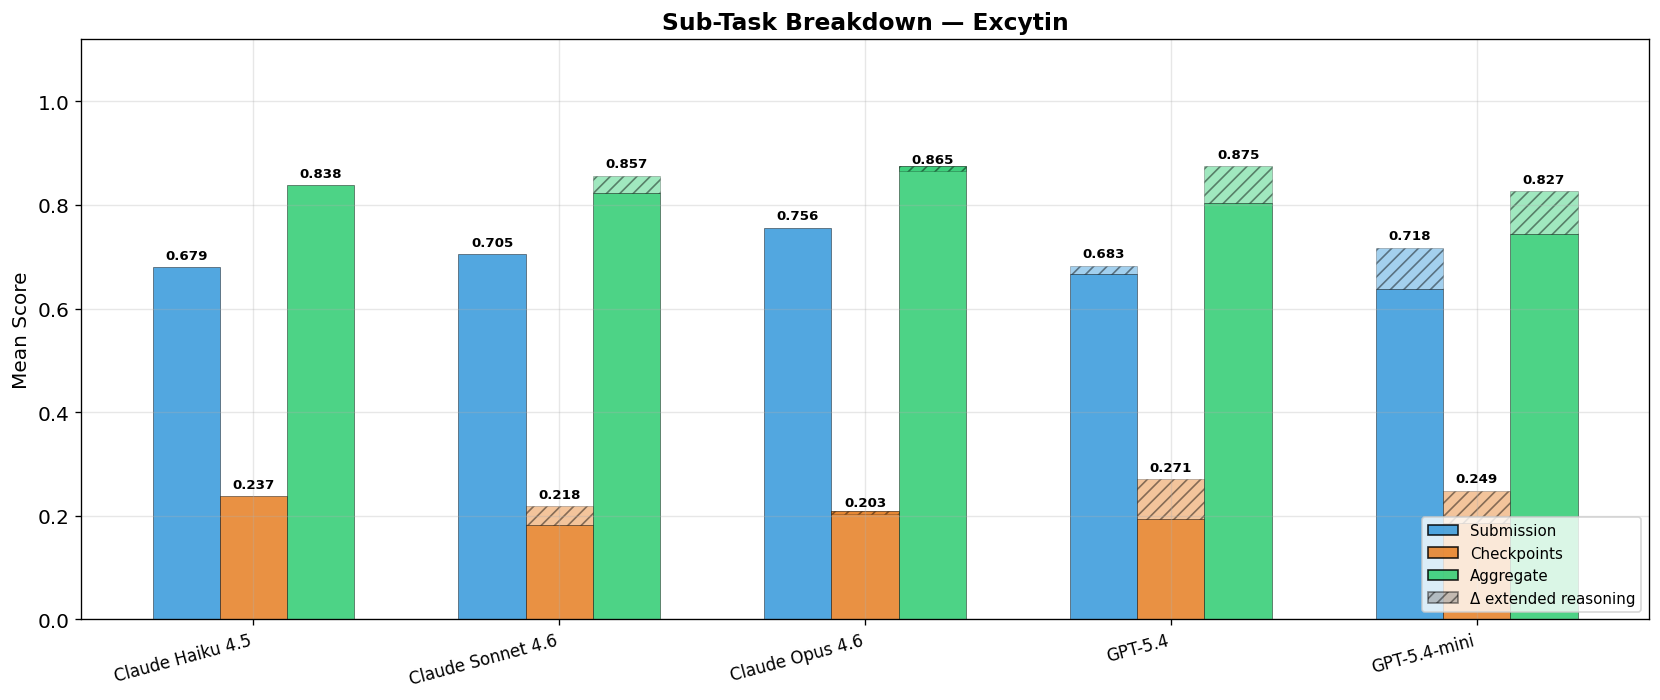

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 6: Sub-task breakdown
# ══════════════════════════════════════════════════════════════════════════════
subtasks_df['category'] = subtasks_df['score_type'].apply(classify_score_type)
cat_means = subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
available_cats = [c for c in ['Submission', 'Checkpoints', 'Aggregate'] if c in cat_means.columns]
cat_means = cat_means.reindex(MODEL_ORDER)[available_cats]

baseline_cat_means = pd.DataFrame()
if len(baseline_subtasks_df) > 0:
    baseline_subtasks_df['category'] = baseline_subtasks_df['score_type'].apply(classify_score_type)
    baseline_cat_means = baseline_subtasks_df.groupby(['model', 'category'])['score'].mean().unstack('category')
    baseline_cat_means = baseline_cat_means.reindex(columns=available_cats)

print('═══ Sub-Task Mean Scores ═══')
print(cat_means.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
cat_plot_colors = ['#3498DB', '#E67E22', '#2ECC71'][:len(available_cats)]
x = np.arange(len(MODEL_ORDER))
bar_width = 0.22
for j, (cat, color) in enumerate(zip(available_cats, cat_plot_colors)):
    offset = (j - len(available_cats)/2 + 0.5) * bar_width
    for i, m in enumerate(MODEL_ORDER):
        fv = cat_means.loc[m, cat]
        has_base = (len(baseline_cat_means) > 0 and m in baseline_cat_means.index
                    and cat in baseline_cat_means.columns and not pd.isna(baseline_cat_means.loc[m, cat]))
        if has_base:
            bv = baseline_cat_means.loc[m, cat]
            ax.bar(x[i]+offset, bv, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
            d = fv - bv
            if abs(d) > 0.001:
                ax.bar(x[i]+offset, abs(d), bottom=bv if d > 0 else fv, width=bar_width, color=color,
                       edgecolor='black', linewidth=0.3, alpha=0.45, hatch='///')
        else:
            ax.bar(x[i]+offset, fv, bar_width, color=color, edgecolor='black', linewidth=0.3, alpha=0.85)
        ax.text(x[i]+offset, fv+0.01, f'{fv:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

handles = [mpatches.Patch(facecolor=c, edgecolor='black', alpha=0.85, label=cat) for cat, c in zip(available_cats, cat_plot_colors)]
handles.append(mpatches.Patch(facecolor='gray', edgecolor='black', alpha=0.45, hatch='///', label='Δ extended reasoning'))
ax.legend(handles=handles, fontsize=9, loc='lower right')
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Mean Score'); ax.set_title('Sub-Task Breakdown — Excytin', fontweight='bold'); ax.set_ylim(0, 1.12)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'subtask_breakdown.png', bbox_inches='tight')
plt.show()

---

## 7. Checkpoint Score Distributions

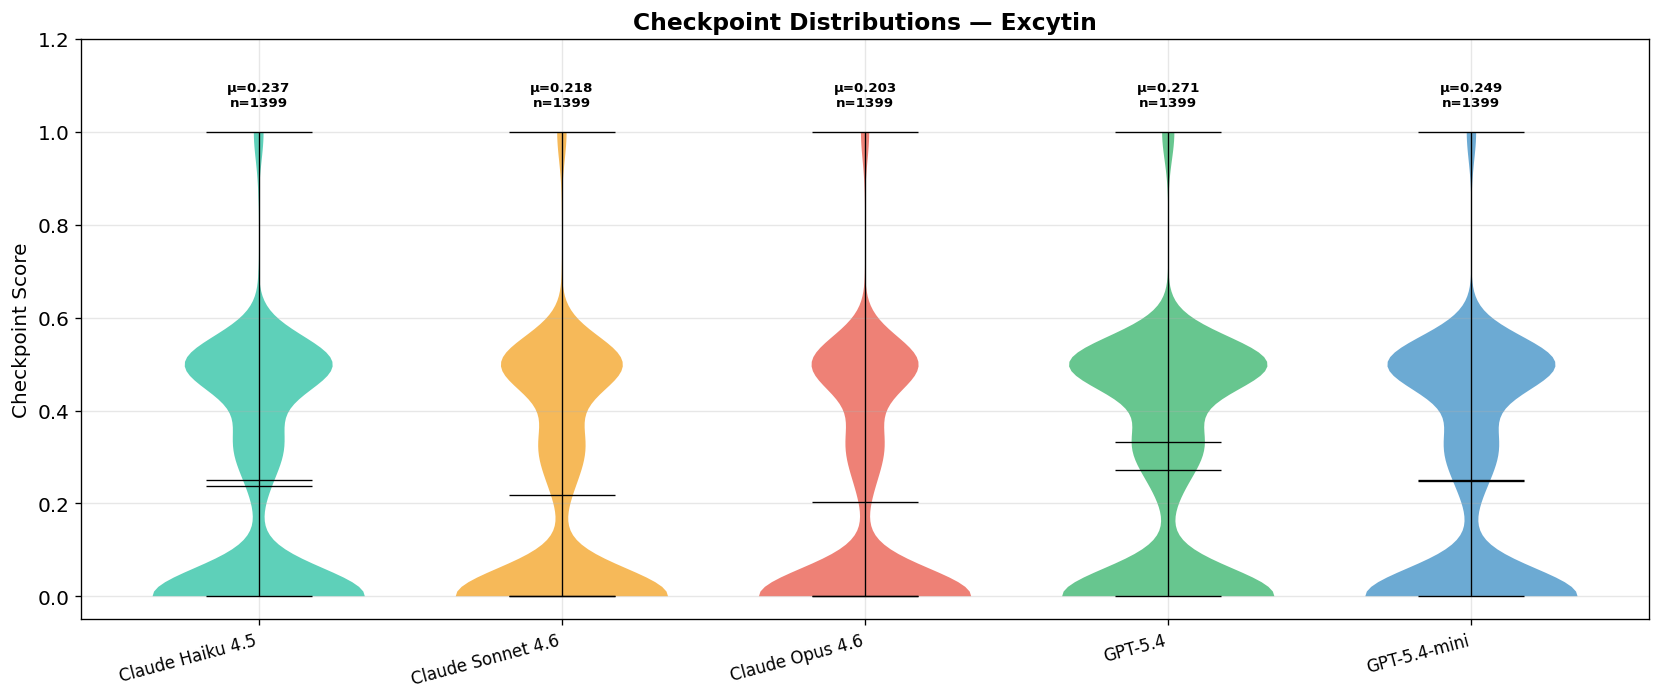

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 7: Checkpoint distributions (violin)
# ══════════════════════════════════════════════════════════════════════════════
checkpoint_df = subtasks_df[subtasks_df['score_type'].str.startswith('checkpoint')].copy()
fig, ax = plt.subplots(figsize=(14, 6))
positions, tick_labels = [], []
for i, model in enumerate(MODEL_ORDER):
    data = checkpoint_df[checkpoint_df['model'] == model]['score'].values
    if len(data) == 0: continue
    vp = ax.violinplot([data], positions=[i], showmeans=True, showmedians=True, widths=0.7)
    for pc in vp['bodies']: pc.set_facecolor(COLORS[model]); pc.set_alpha(0.7)
    for part in ('cmaxes','cmins','cbars','cmeans','cmedians'):
        if part in vp: vp[part].set_edgecolor('black'); vp[part].set_linewidth(0.8)
    ax.text(i, 1.05, f'μ={np.mean(data):.3f}\nn={len(data)}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    positions.append(i); tick_labels.append(model)

ax.set_xticks(positions); ax.set_xticklabels(tick_labels, fontsize=10, rotation=15, ha='right')
ax.set_ylabel('Checkpoint Score'); ax.set_title('Checkpoint Distributions — Excytin', fontweight='bold')
ax.set_ylim(-0.05, 1.2)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'checkpoint_distributions.png', bbox_inches='tight')
plt.show()

---

## 8. Submission vs. Checkpoint Gap Analysis (Excytin-Specific)

### What this measures

This heatmap is **unique to Excytin** — it shows the gap between submission and checkpoint scores **per incident per model**.

- **Red (positive):** Submission > Checkpoints — model guesses correctly without thorough investigation
- **Green (negative):** Checkpoints > Submission — model investigates well but fails to synthesize the answer
- **Yellow (≈0):** Aligned — investigation quality matches answer quality

Models with consistently positive gaps may be unreliable in production — they could be "guessing right" on benchmarks.

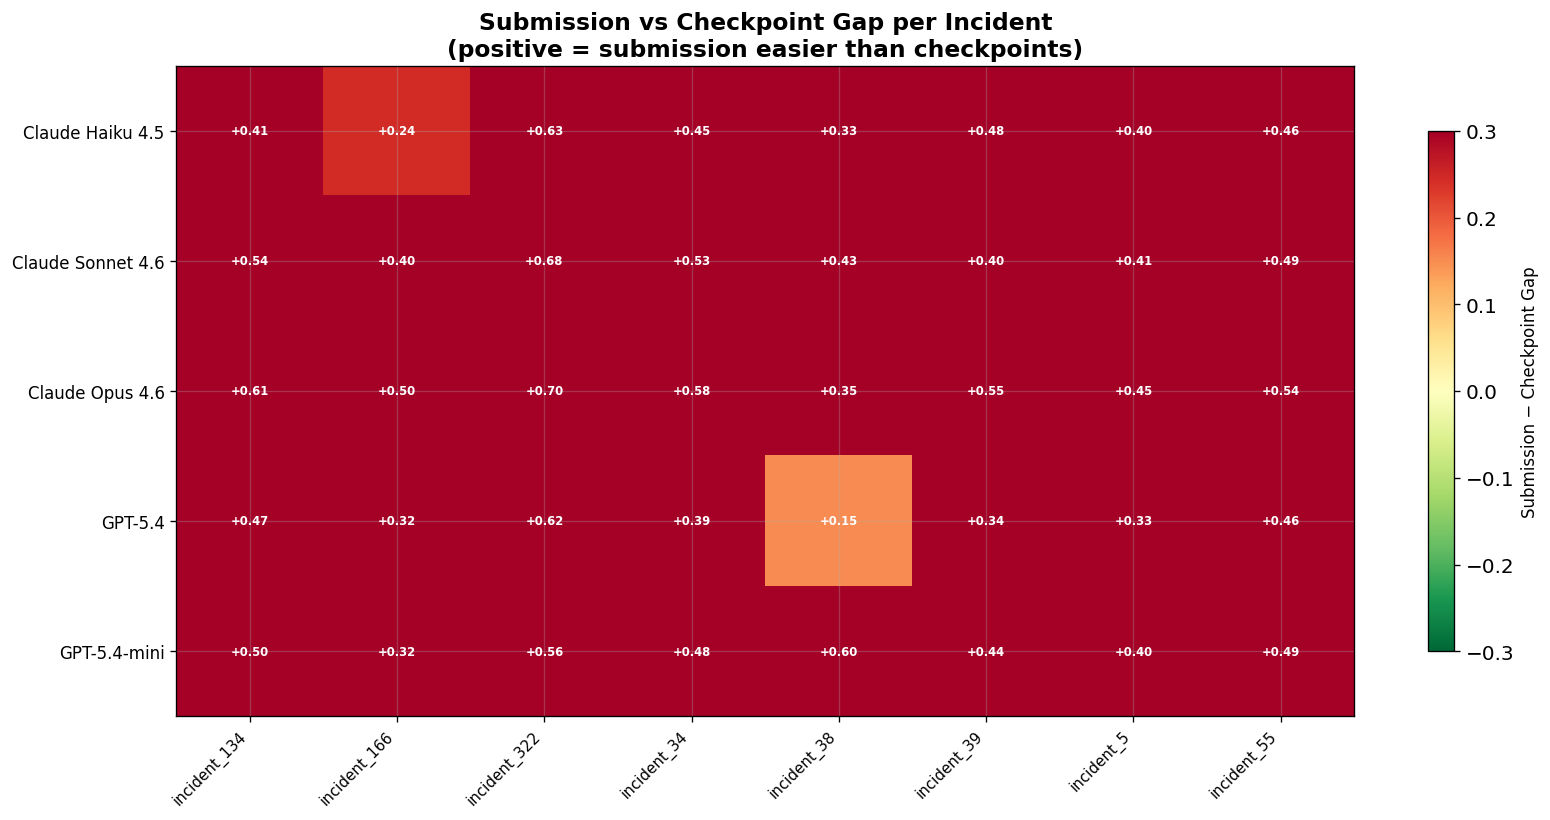

═══ Average Submission–Checkpoint Gap per Model ═══
  Claude Haiku 4.5           avg gap = +0.4256
  Claude Sonnet 4.6          avg gap = +0.4857
  Claude Opus 4.6            avg gap = +0.5346
  GPT-5.4                    avg gap = +0.3850
  GPT-5.4-mini               avg gap = +0.4749


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT 8 (EXCYTIN-SPECIFIC): Submission vs checkpoint gap heatmap
# ══════════════════════════════════════════════════════════════════════════════
sub_means = subtasks_df[subtasks_df['category'] == 'Submission'].groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
cp_means = subtasks_df[subtasks_df['category'] == 'Checkpoints'].groupby(['group', 'model'])['score'].mean().unstack('model').reindex(columns=MODEL_ORDER)
gap = sub_means - cp_means

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(gap.T.values, cmap='RdYlGn_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(gap.index)))
ax.set_xticklabels(gap.index, fontsize=9, rotation=45, ha='right')
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=10)

for i, model in enumerate(MODEL_ORDER):
    for j, inc in enumerate(gap.index):
        val = gap.loc[inc, model]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=7,
                    fontweight='bold', color='white' if abs(val) > 0.15 else 'black')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Submission − Checkpoint Gap', fontsize=10)
ax.set_title('Submission vs Checkpoint Gap per Incident\n(positive = submission easier than checkpoints)', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'submission_checkpoint_gap.png', bbox_inches='tight')
plt.show()

print('═══ Average Submission–Checkpoint Gap per Model ═══')
for m in MODEL_ORDER:
    print(f'  {m:25s}  avg gap = {gap[m].mean():+.4f}')